## California Housing Price Prediction - Linear Regression Project
**Student Name:** Karthik Somaraju  

**Dataset Name:** California Housing Dataset

**Dataset Link:** https://www.geeksforgeeks.org/machine-learning/dataset-for-linear-regression/

### About the dataset
It is collected by U.S. Census in 1990 and this dataset includes various attributes for California districts such as median house value, median income, housing median age, total rooms, total bedrooms, population, households, latitude and longitude.

## Objective
Build a linear regression model to predict the median house value (median_house_value) of a California district using housing and demographic features — location (longitude, latitude), housing age, room/bedroom counts, population, households, median income, and proximity to the ocean. The goal is to understand which factors most strongly influence housing prices and to evaluate how accurately a linear model can estimate house value on unseen data (measured via MSE, MAE, and R²).

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 2. Loading the dataset

In [2]:
# Choose the California Housing CSV file from your computer
from google.colab import files

uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)

print('Shape:', df.shape)
df.head()

Saving housing[1].csv to housing[1].csv
Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 3. Dataset Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## 4. Check Duplicates

In [4]:
df.duplicated().sum()

np.int64(0)

## 5. Remove Duplicates & Handle Missing Values

In [5]:
#In this case there are no duplicates
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

## 6. Verify Duplicates Removed

In [6]:
df.duplicated().sum()

np.int64(0)

## 7. Check Missing Values

In [7]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


## 8. Select Numeric Columns

In [8]:
numeric_cols = df.select_dtypes(include = "number")
print(numeric_cols)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  households  median_income  media

## 9. Outlier Check

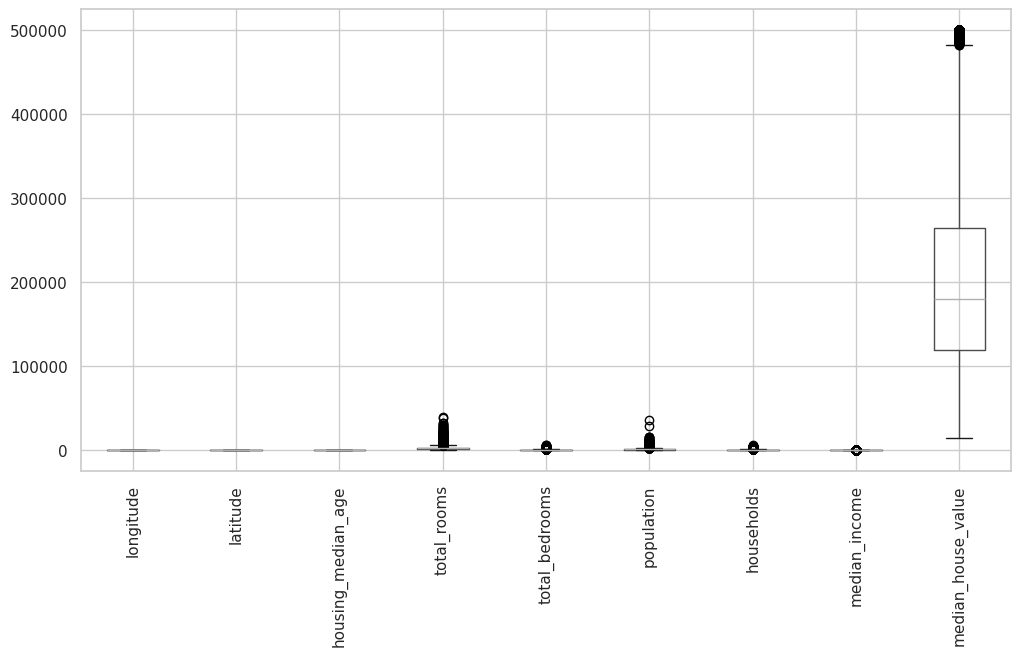

In [9]:
numeric_cols.boxplot(figsize =(12,6))
plt.xticks(rotation = 90)
plt.show()

## 10. Univariate Analysis - Median Income Distribution

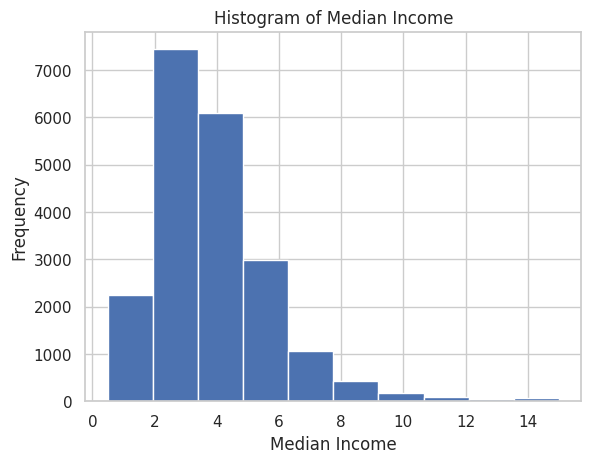

In [10]:
import matplotlib.pyplot as plt
df["median_income"].hist(bins = 10)
plt.title("Histogram of Median Income")
plt.xlabel("Median Income")
plt.ylabel("Frequency")
plt.show()

## 11. Bivariate Analysis - Income vs House Value

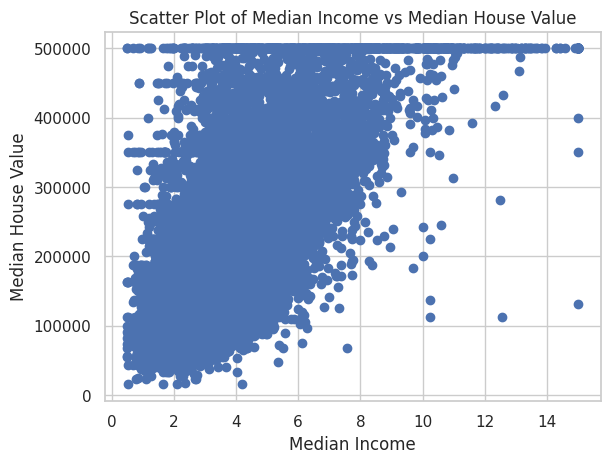

In [11]:
plt.scatter(df["median_income"], df["median_house_value"])
plt.title("Scatter Plot of Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

## 12. Correlation Heatmap

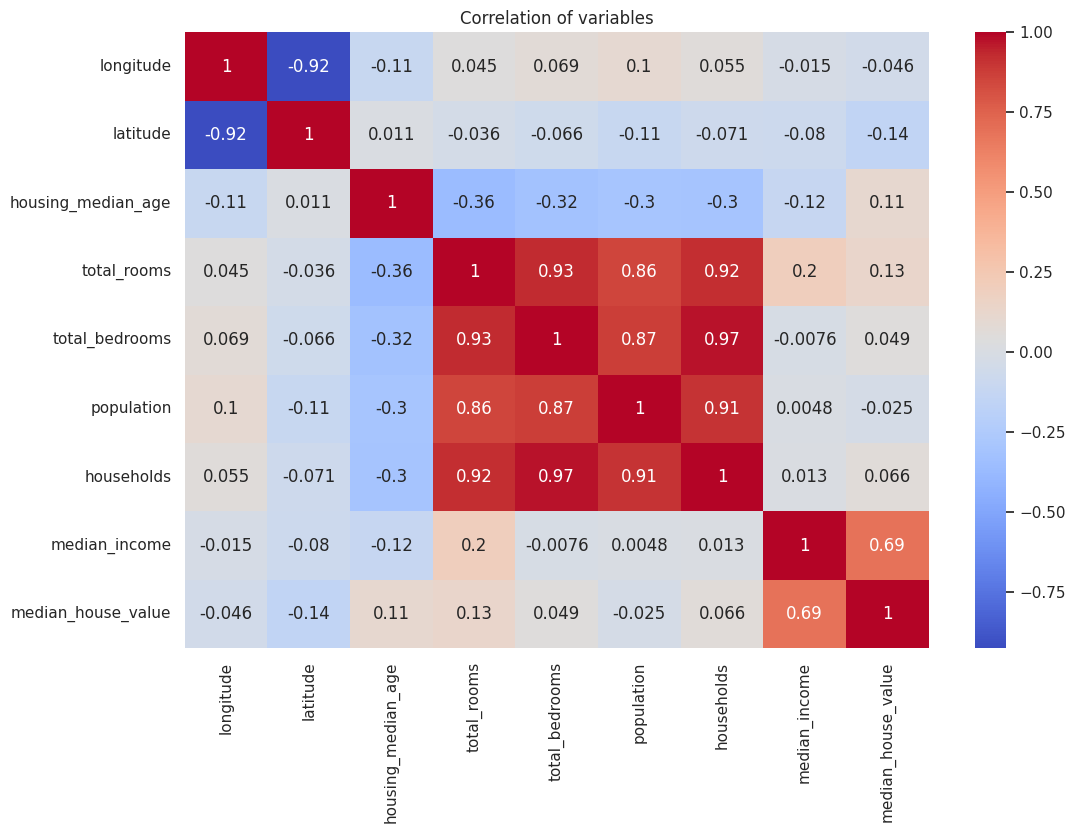

In [12]:
corr = df.corr(numeric_only = True)
plt.figure(figsize= (12,8))
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation of variables")
plt.show()

## 13. Dataset Info (Post Cleaning)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## 14. Ocean Proximity Value Counts

In [14]:
df["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


## 15. Encode Ocean Proximity

In [15]:
df["ocean_proximity"] = (df["ocean_proximity"].map({"<1H OCEAN":0,"INLAND":1,"NEAR OCEAN":2,"NEAR BAY":3,"ISLAND":4}))

## 16. Verify Encoding

In [16]:
df["ocean_proximity"].dtype

dtype('int64')

## 17. Dataset Info (Post Encoding)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 1.6 MB


## 18. Feature-Target Split(X & y  separation)


In [18]:
X = df.drop(columns = ["median_house_value"])
y = df["median_house_value"]

## 19. Preview Features (X)

In [19]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,3
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,3
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,3
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,3
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,3


## 20. Preview Target (y)

In [20]:
y.head()

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


## 21. Train-Test Split

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## 22. Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 23. Import Model & Metrics

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 24. Train Linear Regression Model

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## 25. Predict on Test Set


In [25]:
y_pred = model.predict(X_test)
y_pred

array([ 63103.17218594, 154194.35826257, 250566.28226893, ...,
       441800.94879147, 130420.19916771, 176142.99328572])

## 26. Actual vs Predicted Comparison

In [26]:
comparison = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
20046,47700.0,63103.172186
3024,45800.0,154194.358263
15663,500001.0,250566.282269
20484,218600.0,264573.237131
9814,278000.0,266021.393620
13311,158700.0,153686.059579
7113,198200.0,288404.019574
7668,157500.0,225015.890759
18246,340000.0,253459.461212
5723,446600.0,405590.916860


## 27. Model Evaluation Metrics

In [27]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R-squared:", r2)

Mean Squared Error: 5066374909.744836
Mean Absolute Error: 51829.48868420273
R-squared: 0.6133745270468183


## 28.Unseen data set

> Add blockquote



In [28]:
#Unseen data set
new_data = pd.DataFrame({
    'longitude': [-122.25],
    'latitude': [37.85],
    'housing_median_age': [30],
    'total_rooms': [2000],
    'total_bedrooms': [400],
    'population': [1000],
    'households': [350],
    'median_income': [5],
    'ocean_proximity': [3]
})
new_data_scaled = scaler.transform(new_data)
predicted_house_value = model.predict(new_data_scaled)
print("Predicted Median House Value:", predicted_house_value[0])

Predicted Median House Value: 269811.89723931864


## 29. Model Coefficients & Intercept

In [29]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [-86609.41608799 -90978.72886     15116.84088181 -17342.54571369
  48986.58410332 -44253.95972927  17446.24742869  77019.66316636
  -2025.53917659]
Intercept: 207194.69373788778


## 30. Best Fit Line Visualization

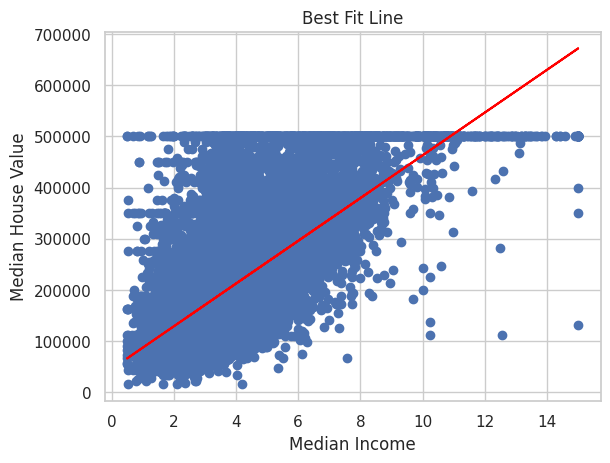

In [30]:
plt.scatter(df['median_income'],df['median_house_value'])
m,c = np.polyfit(df['median_income'],df['median_house_value'],1)
plt.plot(df['median_income'],m*df['median_income']+c,color='red')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('Best Fit Line')
plt.show()